In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

print("All libraries imported successfully!")

All libraries imported successfully!


In [4]:
# Read the datasets
application_df = pd.read_csv("../dataset/application_record.csv")
credit_df = pd.read_csv("../dataset/credit_record.csv")

# Display first 5 rows
print("Application Dataset")
display(application_df.head())

print("Credit Dataset")
display(credit_df.head())

Application Dataset


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


Credit Dataset


,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


In [5]:
print("Application Dataset Information")
application_df.info()

Application Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  str    
 2   FLAG_OWN_CAR         438557 non-null  str    
 3   FLAG_OWN_REALTY      438557 non-null  str    
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  str    
 7   NAME_EDUCATION_TYPE  438557 non-null  str    
 8   NAME_FAMILY_STATUS   438557 non-null  str    
 9   NAME_HOUSING_TYPE    438557 non-null  str    
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-null  int64  
 

In [6]:
application_df.describe()

,ID,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS
count,4.385570e+05,438557.000000,4.385570e+05,438557.000000,438557.000000,438557.0,438557.000000,438557.000000,438557.000000,438557.000000
mean,6.022176e+06,0.427390,1.875243e+05,-15997.904649,60563.675328,1.0,0.206133,0.287771,0.108207,2.194465
std,5.716370e+05,0.724882,1.100869e+05,4185.030007,138767.799647,0.0,0.404527,0.452724,0.310642,0.897207
min,5.008804e+06,0.000000,2.610000e+04,-25201.000000,-17531.000000,1.0,0.000000,0.000000,0.000000,1.000000
25%,5.609375e+06,0.000000,1.215000e+05,-19483.000000,-3103.000000,1.0,0.000000,0.000000,0.000000,2.000000
50%,6.047745e+06,0.000000,1.607805e+05,-15630.000000,-1467.000000,1.0,0.000000,0.000000,0.000000,2.000000
75%,6.456971e+06,1.000000,2.250000e+05,-12514.000000,-371.000000,1.0,0.000000,1.000000,0.000000,3.000000
max,7.999952e+06,19.000000,6.750000e+06,-7489.000000,365243.000000,1.0,1.000000,1.000000,1.000000,20.000000


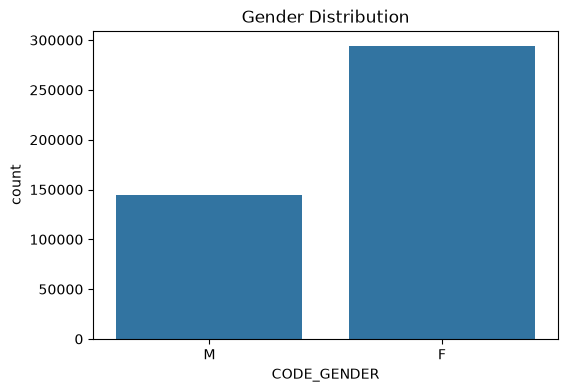

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x="CODE_GENDER", data=application_df)
plt.title("Gender Distribution")
plt.show()

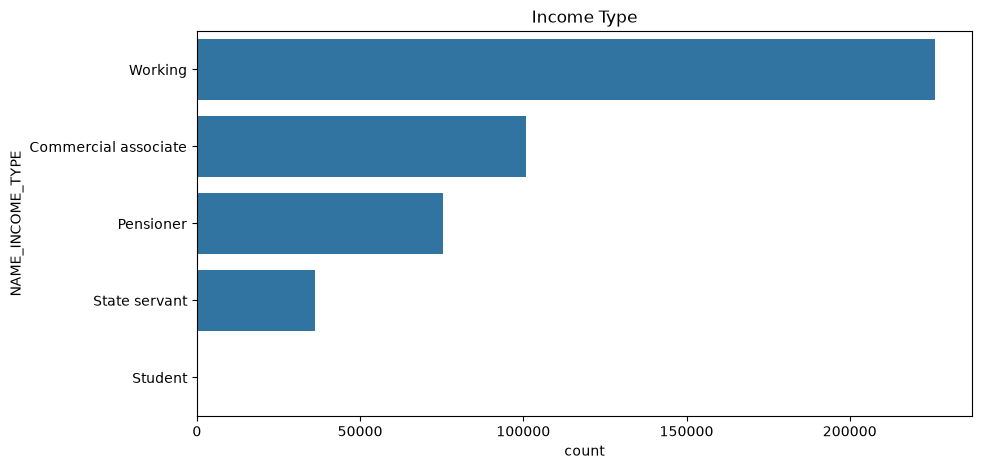

In [8]:
plt.figure(figsize=(10,5))
sns.countplot(y="NAME_INCOME_TYPE", data=application_df)
plt.title("Income Type")
plt.show()

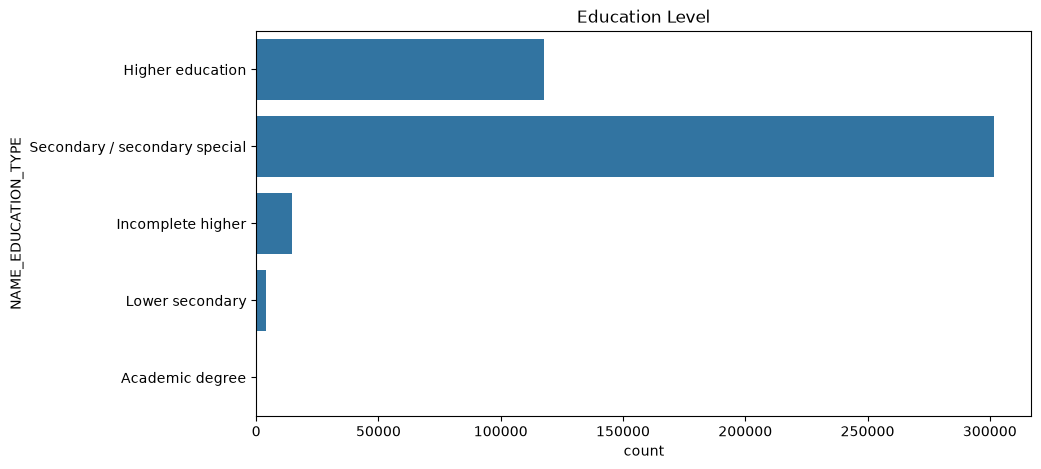

In [9]:
plt.figure(figsize=(10,5))
sns.countplot(y="NAME_EDUCATION_TYPE", data=application_df)
plt.title("Education Level")
plt.show()

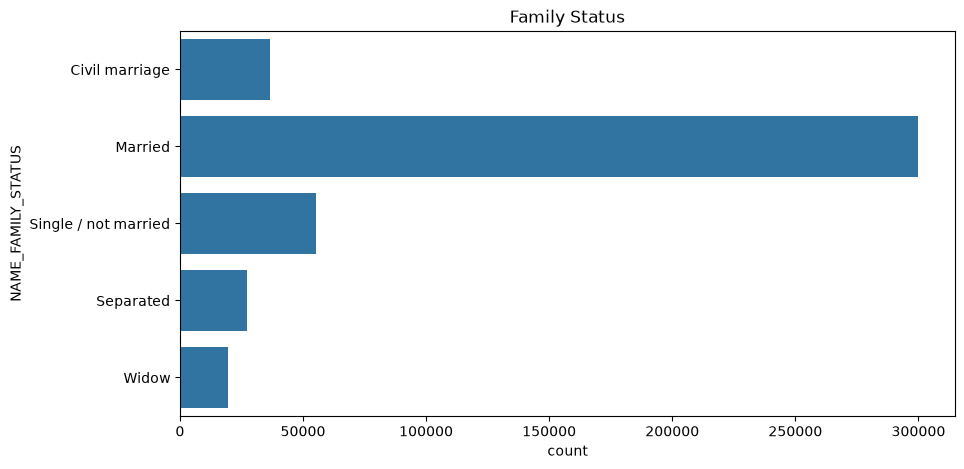

In [10]:
plt.figure(figsize=(10,5))
sns.countplot(y="NAME_FAMILY_STATUS", data=application_df)
plt.title("Family Status")
plt.show()

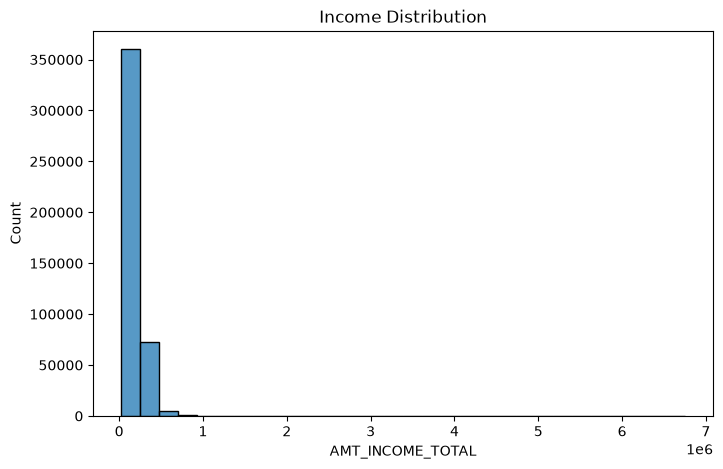

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(application_df["AMT_INCOME_TOTAL"], bins=30)
plt.title("Income Distribution")
plt.show()

In [12]:
## Drop Duplicate Features

In [13]:
# Check duplicate records

print("Duplicate rows in Application Dataset:", application_df.duplicated().sum())
print("Duplicate rows in Credit Dataset:", credit_df.duplicated().sum())

Duplicate rows in Application Dataset: 0
Duplicate rows in Credit Dataset: 0


In [14]:
# Remove duplicate rows

application_df = application_df.drop_duplicates()

credit_df = credit_df.drop_duplicates()

In [15]:
# Verify duplicates after removal

print("Application Dataset:", application_df.duplicated().sum())
print("Credit Dataset:", credit_df.duplicated().sum())

Application Dataset: 0
Credit Dataset: 0


In [16]:
print("Application Dataset Shape:", application_df.shape)
print("Credit Dataset Shape:", credit_df.shape)

Application Dataset Shape: (438557, 18)
Credit Dataset Shape: (1048575, 3)


In [17]:
## Handling Missing Values

In [18]:
# Check missing values
application_df.isnull().sum()

ID                          0
CODE_GENDER                 0
FLAG_OWN_CAR                0
FLAG_OWN_REALTY             0
CNT_CHILDREN                0
AMT_INCOME_TOTAL            0
NAME_INCOME_TYPE            0
NAME_EDUCATION_TYPE         0
NAME_FAMILY_STATUS          0
NAME_HOUSING_TYPE           0
DAYS_BIRTH                  0
DAYS_EMPLOYED               0
FLAG_MOBIL                  0
FLAG_WORK_PHONE             0
FLAG_PHONE                  0
FLAG_EMAIL                  0
OCCUPATION_TYPE        134203
CNT_FAM_MEMBERS             0
dtype: int64

In [19]:
missing_values = application_df.isnull().sum()
missing_values[missing_values > 0]

OCCUPATION_TYPE    134203
dtype: int64

In [20]:
application_df["OCCUPATION_TYPE"] = application_df["OCCUPATION_TYPE"].fillna("Unknown")

In [21]:
application_df.isnull().sum()

ID                     0
CODE_GENDER            0
FLAG_OWN_CAR           0
FLAG_OWN_REALTY        0
CNT_CHILDREN           0
AMT_INCOME_TOTAL       0
NAME_INCOME_TYPE       0
NAME_EDUCATION_TYPE    0
NAME_FAMILY_STATUS     0
NAME_HOUSING_TYPE      0
DAYS_BIRTH             0
DAYS_EMPLOYED          0
FLAG_MOBIL             0
FLAG_WORK_PHONE        0
FLAG_PHONE             0
FLAG_EMAIL             0
OCCUPATION_TYPE        0
CNT_FAM_MEMBERS        0
dtype: int64

In [22]:
# Create Family_Size feature

application_df["Family_Size"] = (
    application_df["CNT_FAM_MEMBERS"] + application_df["CNT_CHILDREN"]
)

In [23]:
# Convert negative days into positive values

application_df["DAYS_BIRTH"] = application_df["DAYS_BIRTH"].abs()
application_df["DAYS_EMPLOYED"] = application_df["DAYS_EMPLOYED"].abs()

In [24]:
application_df.drop(
    columns=["FLAG_MOBIL"],
    inplace=True
)

In [25]:
merged_df = pd.merge(
    application_df,
    credit_df,
    on="ID",
    how="inner"
)

print("Merged Dataset Shape:", merged_df.shape)

merged_df.head()

Merged Dataset Shape: (777715, 20)


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,Family_Size,MONTHS_BALANCE,STATUS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,12005,4542,1,0,0,Unknown,2.0,2.0,0,C
1,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,12005,4542,1,0,0,Unknown,2.0,2.0,-1,C
2,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,12005,4542,1,0,0,Unknown,2.0,2.0,-2,C
3,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,12005,4542,1,0,0,Unknown,2.0,2.0,-3,C
4,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,12005,4542,1,0,0,Unknown,2.0,2.0,-4,C


In [26]:
def approval_status(status):

    if status in ["C", "X", "0"]:
        return 1      # Approved

    else:
        return 0      # Not Approved


merged_df["TARGET"] = merged_df["STATUS"].apply(approval_status)

In [27]:
merged_df[["STATUS", "TARGET"]].head()

,STATUS,TARGET
0,C,1
1,C,1
2,C,1
3,C,1
4,C,1


In [28]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

categorical_columns = merged_df.select_dtypes(include="object").columns

print(categorical_columns)

Index(['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_INCOME_TYPE',
       'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE',
       'OCCUPATION_TYPE', 'STATUS'],
      dtype='str')


In [29]:
for col in categorical_columns:

    merged_df[col] = encoder.fit_transform(merged_df[col])

merged_df.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,...,DAYS_EMPLOYED,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,Family_Size,MONTHS_BALANCE,STATUS,TARGET
0,5008804,1,1,1,0,427500.0,4,1,0,4,...,4542,1,0,0,17,2.0,2.0,0,6,1
1,5008804,1,1,1,0,427500.0,4,1,0,4,...,4542,1,0,0,17,2.0,2.0,-1,6,1
2,5008804,1,1,1,0,427500.0,4,1,0,4,...,4542,1,0,0,17,2.0,2.0,-2,6,1
3,5008804,1,1,1,0,427500.0,4,1,0,4,...,4542,1,0,0,17,2.0,2.0,-3,6,1
4,5008804,1,1,1,0,427500.0,4,1,0,4,...,4542,1,0,0,17,2.0,2.0,-4,6,1


In [30]:
merged_df.to_csv(
    "../dataset/final_credit_card_dataset.csv",
    index=False
)

In [31]:
# Epic 4: Model Building

## Logistic Regression Model

In [32]:
# Features and Target

X = merged_df.drop("TARGET", axis=1)
y = merged_df["TARGET"]

# Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (622172, 20)
Testing Data Shape: (155543, 20)


In [33]:
from sklearn.linear_model import LogisticRegression

# Create Logistic Regression model
logistic_model = LogisticRegression(max_iter=1000)

# Train the model
logistic_model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [34]:
# Predict on test data
y_pred = logistic_model.predict(X_test)

In [35]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9853095285548048

Confusion Matrix:
[[     0   2285]
 [     0 153258]]

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      2285
           1       0.99      1.00      0.99    153258

    accuracy                           0.99    155543
   macro avg       0.49      0.50      0.50    155543
weighted avg       0.97      0.99      0.98    155543



In [36]:
## Random Forest Model

In [37]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Accuracy: 1.0

Confusion Matrix:
[[  2285      0]
 [     0 153258]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2285
           1       1.00      1.00      1.00    153258

    accuracy                           1.00    155543
   macro avg       1.00      1.00      1.00    155543
weighted avg       1.00      1.00      1.00    155543



In [38]:
## Decision Tree Model

In [39]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Create Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)

# Train the model
dt_model.fit(X_train, y_train)

# Predict
y_pred_dt = dt_model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred_dt))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

Accuracy: 1.0

Confusion Matrix:
[[  2285      0]
 [     0 153258]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2285
           1       1.00      1.00      1.00    153258

    accuracy                           1.00    155543
   macro avg       1.00      1.00      1.00    155543
weighted avg       1.00      1.00      1.00    155543



In [40]:
## Model Comparison

In [41]:
# Compare model accuracies

print("Model Comparison")
print("----------------------------")
print("Logistic Regression :", accuracy_score(y_test, y_pred))
print("Random Forest       :", accuracy_score(y_test, y_pred_rf))
print("Decision Tree       :", accuracy_score(y_test, y_pred_dt))

Model Comparison
----------------------------
Logistic Regression : 0.9853095285548048
Random Forest       : 1.0
Decision Tree       : 1.0


In [42]:
## Save Best Model

In [43]:
import joblib
import os

# Create models folder if it doesn't exist
os.makedirs("../models", exist_ok=True)

# Save the Random Forest model
joblib.dump(rf_model, "../models/credit_card_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [44]:
print(X.columns.tolist())

['ID', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'Family_Size', 'MONTHS_BALANCE', 'STATUS']


In [45]:
pip install flask


Note: you may need to restart the kernel to use updated packages.
